<a href="https://colab.research.google.com/github/PIETROpelzi/Progetto_AI/blob/main/Progetto_MachineLearning_Film.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub
import kagglehub

# Scarica l'ultima versione del dataset
path = kagglehub.dataset_download("rudrakumargupta/animation-movies-complete-dataset-18782029")

print("Il file si trova qui:", path)

100%|██████████| 6.65M/6.65M [00:00<00:00, 128MB/s]

Extracting files...


Il file si trova qui: /root/.cache/kagglehub/datasets/rudrakumargupta/animation-movies-complete-dataset-18782029/versions/1


Caricamento del file: /root/.cache/kagglehub/datasets/rudrakumargupta/animation-movies-complete-dataset-18782029/versions/1/animation_movies_enriched_1878_2029.csv
Allenamento del modello Random Forest in corso...

--- RISULTATI FINALI ---
Errore Medio Assoluto (MAE): 0.58
Punteggio R2 (Precisione): 0.37


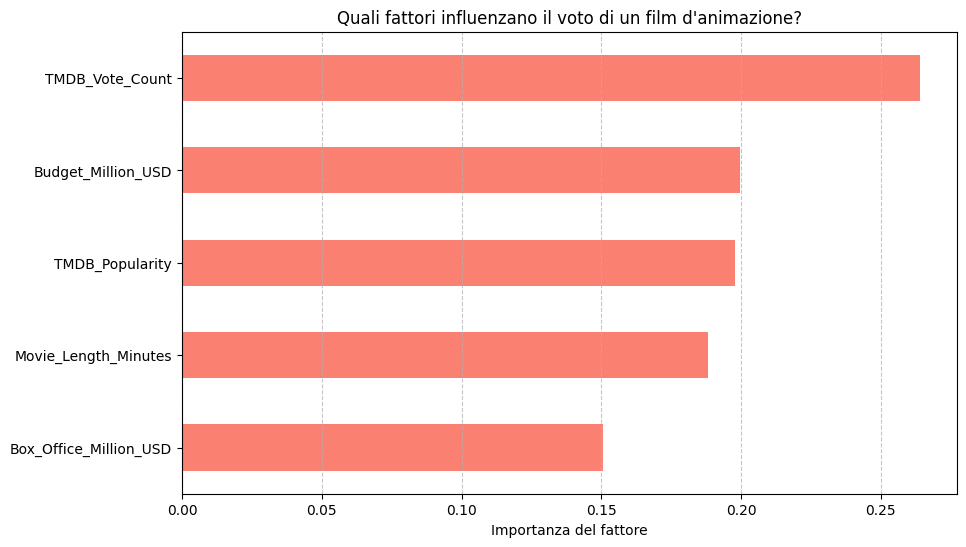

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. TROVA IL FILE CSV NELLA CARTELLA DI KAGGLEHUB
# Cerchiamo il file .csv all'interno della cartella dove kagglehub lo ha scaricato
files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_path = os.path.join(path, files[0])
print(f"Caricamento del file: {csv_path}")

# 2. CARICAMENTO DATI
df = pd.read_csv(csv_path)

# 3. PULIZIA DEI DATI (Data Cleaning)
# Usiamo le colonne numeriche più interessanti per prevedere il voto (TMDB_Rating)
features_numeriche = ['Budget_Million_USD', 'TMDB_Popularity', 'Movie_Length_Minutes', 'TMDB_Vote_Count', 'Box_Office_Million_USD']
df_clean = df.dropna(subset=features_numeriche + ['TMDB_Rating'])

X = df_clean[features_numeriche]
y = df_clean['TMDB_Rating']

# 4. DIVISIONE IN TRAINING E TEST SET (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. CREAZIONE E ALLENAMENTO DEL MODELLO (Random Forest)
print("Allenamento del modello Random Forest in corso...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. VALUTAZIONE DEI RISULTATI
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n--- RISULTATI FINALI ---")
print(f"Errore Medio Assoluto (MAE): {mae:.2f}")
print(f"Punteggio R2 (Precisione): {r2:.2f}")

# 7. GRAFICO DELLE IMPORTANZE
importances = pd.Series(model.feature_importances_, index=features_numeriche)
plt.figure(figsize=(10,6))
importances.sort_values().plot(kind='barh', color='salmon')
plt.title('Quali fattori influenzano il voto di un film d\'animazione?')
plt.xlabel('Importanza del fattore')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()